In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=os.environ.get("ROBOFLOW_API_KEY"))
project = rf.workspace("cs435").project("ships-aerial-images-emeep-l6lcb")
version = project.version(5)
dataset = version.download("yolov8") # Or Yolov5nu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 133.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ships-aerial-images-5 in yolov11:: 100%|██████████| 19244/19244 [00:02<00:00, 6602.22it/s]


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLOv5n or Yolov8 model
model = YOLO("yolov5nu.pt")


results = model.train(data="/content/ships-aerial-images-5/data.yaml", epochs=80, imgsz=640, device = 0)

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ships-aerial-images-5/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5nu.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T


image 1/1 /content/ships-aerial-images-5/test/images/02e39612d_jpg.rf.04e1825d49557feadaaa6459b4792667.jpg: 640x640 2 ships, 10.7ms
Speed: 2.0ms preprocess, 10.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


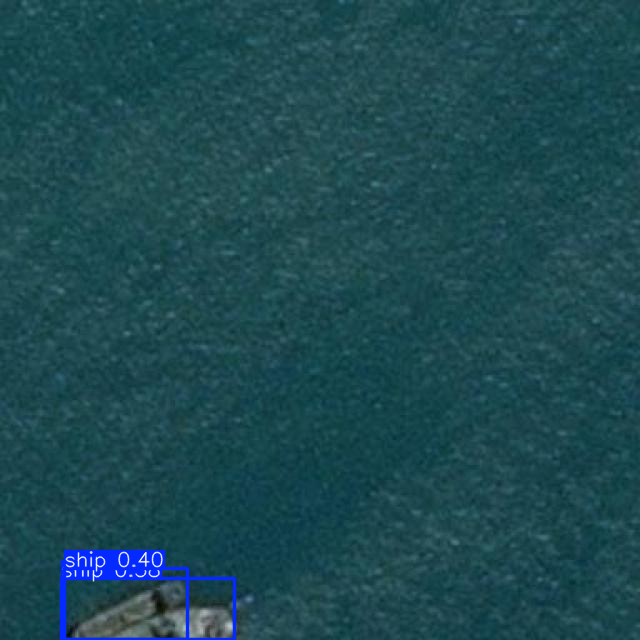

In [ ]:
from google.colab.patches import cv2_imshow
results = model("/content/ships-aerial-images-5/test/images/02e39612d_jpg.rf.04e1825d49557feadaaa6459b4792667.jpg")
cv2_imshow(results[0].plot())

Image shape: 640x640
Occlusion patch: 40x40, stride: 20
Found 1 ship detection(s)
Performing occlusion analysis...


100%|██████████| 31/31 [00:10<00:00,  2.82it/s]


Results saved to: /content/runs/detect/occlusion_analysis.png


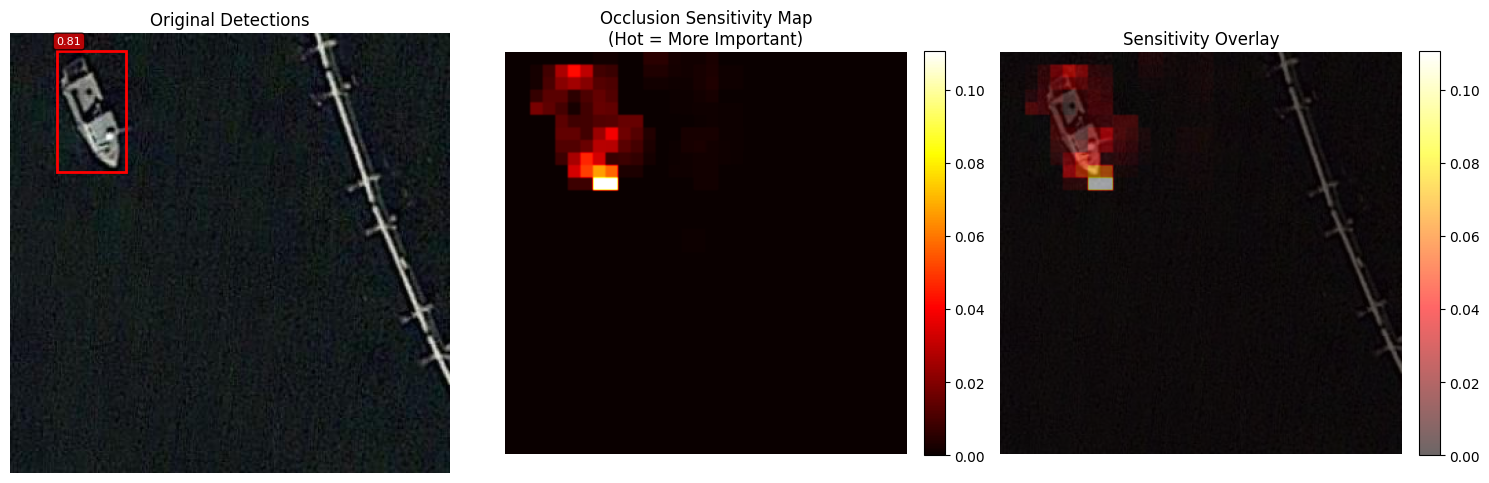

In [ ]:
import cv2
import numpy as np
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

class OcclusionAnalyzer:
    def __init__(self, model_path, device='cuda' if torch.cuda.is_available() else 'cpu'):

        self.model = YOLO(model_path)
        self.device = device
        self.model.to(device)
        self.class_names = self.model.names

    def calculate_iou(self, box1, box2):

        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        intersection = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

        union = area1 + area2 - intersection
        return intersection / union if union > 0 else 0

    def get_original_detections(self, image, target_class='ship', confidence_threshold=0.5):

        results = self.model(image, verbose=False)
        detections = []

        for detection in results[0].boxes:
            cls = int(detection.cls)
            conf = float(detection.conf)
            bbox = detection.xyxy[0].cpu().numpy()

            if self.class_names[cls] == target_class and conf > confidence_threshold:
                detections.append({
                    'bbox': bbox,
                    'confidence': conf,
                    'class': self.class_names[cls]
                })

        return detections, results[0].plot()
    def occlusion_analysis(self, image_path, target_class='ship',
                         patch_size=32, stride=16, confidence_threshold=0.5,
                         occlusion_value=128, save_path=None):



        if isinstance(image_path, str):
            image = cv2.imread(image_path)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image_rgb = image_path.copy()

        original_image = image_rgb.copy()
        h, w = image_rgb.shape[:2]

        print(f"Image shape: {h}x{w}")
        print(f"Occlusion patch: {patch_size}x{patch_size}, stride: {stride}")

        original_detections, detection_plot = self.get_original_detections(
            original_image, target_class, confidence_threshold
        )

        if not original_detections:
            print(f"No {target_class} detections found with confidence > {confidence_threshold}")
            return None, None, None, None

        print(f"Found {len(original_detections)} {target_class} detection(s)")


        sensitivity_map = np.zeros((h, w))
        count_map = np.zeros((h, w))


        print("Performing occlusion analysis...")
        for y in tqdm(range(0, h - patch_size + 1, stride)):
            for x in range(0, w - patch_size + 1, stride):

                occluded_image = original_image.copy()
                occluded_image[y:y+patch_size, x:x+patch_size] = occlusion_value


                occluded_detections = self.get_original_detections(
                    occluded_image, target_class, confidence_threshold
                )[0]


                total_confidence_drop = 0
                valid_detections = 0

                for orig_det in original_detections:
                    max_current_conf = 0


                    for occ_det in occluded_detections:
                        iou = self.calculate_iou(orig_det['bbox'], occ_det['bbox'])
                        if iou > 0.3:
                            max_current_conf = max(max_current_conf, occ_det['confidence'])


                    if max_current_conf == 0:
                        confidence_drop = orig_det['confidence']
                    else:
                        confidence_drop = orig_det['confidence'] - max_current_conf

                    if confidence_drop > 0:
                        total_confidence_drop += confidence_drop
                        valid_detections += 1


                if valid_detections > 0:
                    avg_drop = total_confidence_drop / valid_detections
                    sensitivity_map[y:y+patch_size, x:x+patch_size] += avg_drop
                    count_map[y:y+patch_size, x:x+patch_size] += 1


        sensitivity_map = np.divide(sensitivity_map, count_map,
                                   out=np.zeros_like(sensitivity_map),
                                   where=count_map != 0)


        sensitivity_map = cv2.GaussianBlur(sensitivity_map, (5, 5), 0)

        return original_image, sensitivity_map, original_detections, detection_plot

    def visualize_results(self, original_image, sensitivity_map, detections,
                         save_path=None, figsize=(15, 5)):


        fig, axes = plt.subplots(1, 3, figsize=figsize)


        axes[0].imshow(original_image)
        for det in detections:
            bbox = det['bbox']
            conf = det['confidence']
            rect = plt.Rectangle(
                (bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                fill=False, color='red', linewidth=2, label=f'{conf:.2f}'
            )
            axes[0].add_patch(rect)
            axes[0].text(bbox[0], bbox[1]-10, f'{conf:.2f}',
                        bbox=dict(boxstyle="round,pad=0.3", fc='red', alpha=0.7),
                        color='white', fontsize=8)
        axes[0].set_title('Original Detections')
        axes[0].axis('off')

        im = axes[1].imshow(sensitivity_map, cmap='hot')
        axes[1].set_title('Occlusion Sensitivity Map\n(Hot = More Important)')
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)


        axes[2].imshow(original_image)
        overlay = axes[2].imshow(sensitivity_map, cmap='hot', alpha=0.6)
        axes[2].set_title('Sensitivity Overlay')
        axes[2].axis('off')
        plt.colorbar(overlay, ax=axes[2], fraction=0.046, pad=0.04)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"Results saved to: {save_path}")

        plt.show()

        return fig


analyzer = OcclusionAnalyzer('/content/runs/detect/train2/weights/best.pt')


original_image, sensitivity_map, detections, detection_plot = analyzer.occlusion_analysis(
    image_path='/content/ships-aerial-images-5/test/images/GE_357_jpg.rf.b1fe2f9fceb461a7a25b1514bf1bd44d.jpg',
    target_class='ship',
    patch_size=40,
    stride=20,
    confidence_threshold=0.5
)


if sensitivity_map is not None:
    analyzer.visualize_results(
        original_image,
        sensitivity_map,
        detections,
        save_path='/content/runs/detect/occlusion_analysis.png'
    )


image 1/1 /content/ships-aerial-images-5/test/images/GE_357_jpg.rf.b1fe2f9fceb461a7a25b1514bf1bd44d.jpg: 640x640 1 ship, 8.4ms
Speed: 2.1ms preprocess, 8.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


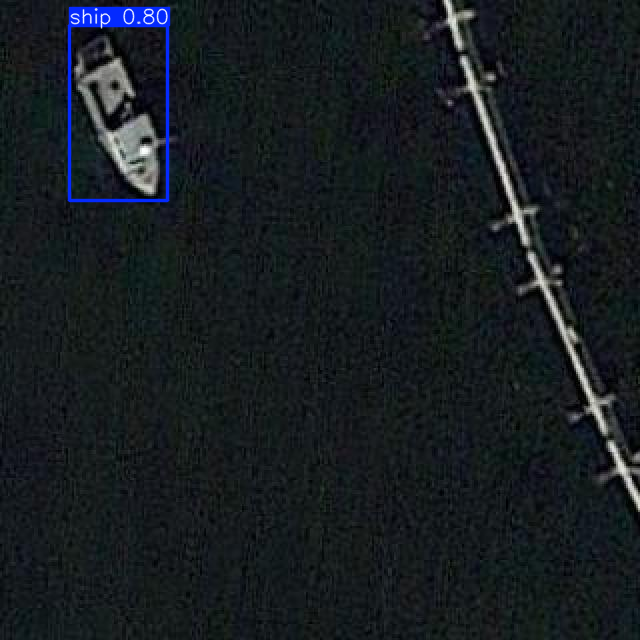

In [ ]:
from google.colab.patches import cv2_imshow
results = model("/content/ships-aerial-images-5/test/images/GE_357_jpg.rf.b1fe2f9fceb461a7a25b1514bf1bd44d.jpg")
cv2_imshow(results[0].plot())

In [ ]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torchvision.transforms as transforms

class SimpleSaliency:
    def __init__(self, model_path):
        self.model = YOLO(model_path)
        self.class_names = self.model.names

    def generate_attention_map(self, image_path, target_class='ship'):

        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


        confidence_thresholds = [0.1, 0.3, 0.5, 0.7]
        attention_map = np.zeros(image.shape[:2])

        for conf_thresh in confidence_thresholds:
            results = self.model(image_rgb, conf=conf_thresh, verbose=False)

            for detection in results[0].boxes:
                cls = int(detection.cls)
                conf = float(detection.conf)
                bbox = detection.xyxy[0].cpu().numpy()

                if self.class_names[cls] == target_class:
                    x1, y1, x2, y2 = map(int, bbox)


                    weight = conf * (1 + conf_thresh)
                    attention_map[y1:y2, x1:x2] += weight


        if attention_map.max() > 0:
            attention_map = attention_map / attention_map.max()


        final_results = self.model(image_rgb, conf=0.5, verbose=False)
        detections = []
        for detection in final_results[0].boxes:
            cls = int(detection.cls)
            conf = float(detection.conf)
            bbox = detection.xyxy[0].cpu().numpy()

            if self.class_names[cls] == target_class:
                detections.append({
                    'bbox': bbox,
                    'confidence': conf,
                    'class': self.class_names[cls]
                })

        return image_rgb, attention_map, detections

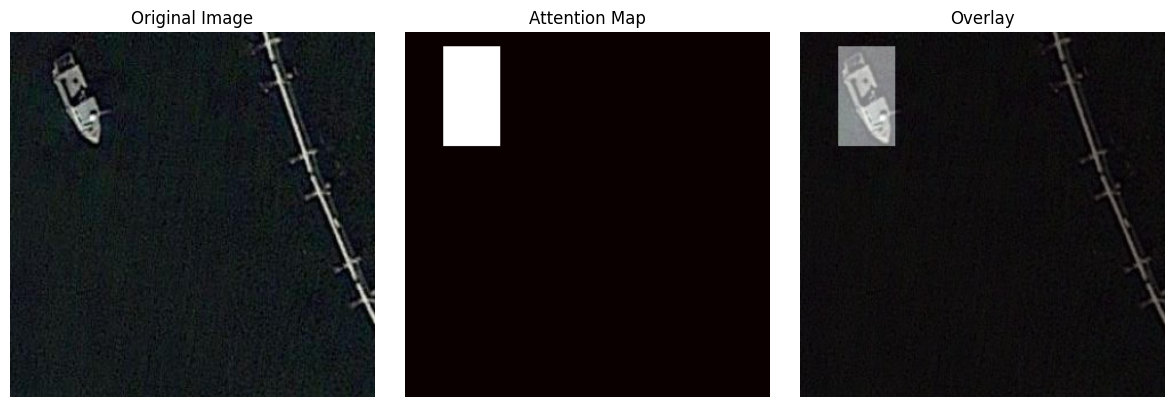

In [ ]:
saliency = SimpleSaliency('/content/runs/detect/train2/weights/best.pt')
image, attention_map, detections = saliency.generate_attention_map(
    '/content/ships-aerial-images-5/test/images/GE_357_jpg.rf.b1fe2f9fceb461a7a25b1514bf1bd44d.jpg',
    target_class='ship'
)
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(132)
plt.imshow(attention_map, cmap='hot')
plt.title('Attention Map')
plt.axis('off')

plt.subplot(133)
plt.imshow(image)
plt.imshow(attention_map, cmap='hot', alpha=0.5)
plt.title('Overlay')
plt.axis('off')

plt.tight_layout()
plt.savefig('/content/runs/detect/simple_saliency.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!cp -r "/content/runs/detect/" "/content/drive/MyDrive/YOLOv5(Cropped) - 80 epochs"